<a href="https://colab.research.google.com/github/shiro-seminar/Econometrics-proto/blob/main/multi_item_mech_general_colab_(3*7-%EF%BC%92).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 複数財配分メカニズムの学習 — n人 × k財 / シナジー α 一般版（Colab GPU）

2人×5財に固定されていた `multi_item_mech` を **任意の n 人 × k 財**・**全ハイパーパラメータ可変**・
**GPU 高速化**した自己完結ノートブックです。

## 問題設定
- **エージェント** n 人、**財** k 個（不可分、disposal なし＝全財を誰かに配る）。
- 配分は「各財をどのエージェントに渡すか」で決まり、総数は **K = nᵏ**。
- 効用（基数）: 各 i は財ごとの評価値 `v[i,j] ~ U(v_min, v_max)` と **シナジー** `α[i] ~ U(α_min, α_max)` を持ち、
  バンドル S に対し

  $$u_i(S) = \sum_{j \in S} v_{ij} + (|S|-1)\,\alpha_i \quad (S\neq\varnothing,\ \text{空なら }0)$$

  α>0 なら**補完財**（まとめ持ちが得）、α<0 なら**代替財**、α=0 なら**純加法的**。

## 学習する性質（Sönmez 1999 の不可能性が背景）
- **IR（個人合理性）**: 交換後の効用 ≥ 初期保有の効用 → **出力マスクで構造的に強制**（常に満たす）。
- **SP（耐戦略性）**: 嘘の申告で得しない → **誤申告サンプリング**で近似した regret を最小化。
- **効率**: 社会厚生 welfare = Σ_i u_i を目的関数にしつつ、**PE（パレート効率）違反を罰則項として直接最小化**（出力が他配分にパレート支配されないようにする）。

SP+IR+効率の完全両立は一般に不可能（TTC 等の core に限られる）。本ノートは
**IR を厳守・SP を罰則最小化しつつ効率損失を抑える Second-Best メカニズム**を NN で探索する。

> ⚠️ **規模に注意:** K = nᵏ は指数増加します（例: 3⁵=243, 3⁸=6561, 4⁶=4096, 3¹⁰=59049）。
> SP 計算では `[batch × misreport_samples × n × K]` のテンソルを作るので、大きい設定では
> `batch_size` / `misreport_samples` を下げてください（下のセルで必要メモリを概算表示します）。


## 0. GPU を有効化
Colab メニュー: **ランタイム → ランタイムのタイプを変更 → ハードウェア アクセラレータ → GPU (T4 等)**。
その後、上から順に実行（Runtime → Run all）してください。

In [26]:
import math, time
from dataclasses import dataclass, asdict
from typing import Tuple, Callable

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import matplotlib.pyplot as plt
    _HAS_PLT = True
except Exception:
    _HAS_PLT = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device :", device)
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU not detected. Runtime -> Change runtime type -> GPU")

PyTorch: 2.11.0+cu128
Device : cuda
GPU    : NVIDIA L4


## 1. ハイパーパラメータ（ここだけ編集すれば全部変わる）

`num_agents`(n)・`num_items`(k)・`alpha_min/max`(シナジー α) を含め、すべてここで設定します。

In [27]:
@dataclass
class Config:
    # ===== 問題サイズ (n 人 × k 財) =====
    num_agents: int = 3          # n
    num_items:  int = 7          # k   (K = n^k 配分)

    # ===== 効用モデル  u_i(S)=sum_{j in S} v_ij + (|S|-1)*alpha_i =====
    v_min: float = 0.0
    v_max: float = 1.0
    alpha_min: float = 0.0       # シナジー α 下限 (負=代替財)
    alpha_max: float = 0.0       # シナジー α 上限 (正=補完財). 純加法は両方 0.0

    # ===== 初期保有 (endowment) =====
    ensure_nonempty_endowment: bool = False  # True で全員が必ず1財以上保有 (要 k>=n)

    # ===== モデル (MLP) =====
    hidden: int = 256
    depth:  int = 4
    dropout: float = 0.0

    # ===== 学習 =====
    batch_size: int = 256
    steps: int = 20000
    lr: float = 1e-4
    grad_clip: float = 1.0
    seed: int = 0
    tag: str = "run"          # 実験ラベル (記録フォルダ名・マスター表の行ラベルに使う)
    notes: str = ""           # 自由メモ (マスター表に残る)

    # ===== softmax 温度とアニーリング (終盤に確定化) =====
    temperature: float = 1.0
    anneal_last_steps: int = 5000   # 最後の N step で温度を temp_end へ線形に下げる
    temp_end: float = 0.05

    # ===== 学習率スケジュール =====
    lr_milestones: Tuple[int, ...] = (12000, 17000)
    lr_gamma: float = 0.5

    # ===== Augmented Lagrangian (IR & SP の罰則) =====
    enforce_ir_by_mask: bool = True  # IR をマスクで厳守 (推奨, 実IR違反~0)
    lambda_ir: float = 0.0
    lambda_sp: float = 0.0
    rho: float = 5.0
    dual_update_every: int = 200
    rho_mult: float = 1.01
    rho_max: float = 100.0
    ir_target: float = 0.05
    sp_target: float = 0.05
    lambda_pe: float = 0.0        # PE (パレート効率) 違反ペナルティの双対変数
    pe_target: float = 0.02
    welfare_weight: float = 1.0   # 効率(welfare)目的の重み. 0 にすると PE ペナルティのみで効率を担保

    # ===== SP 近似 (誤申告サンプリング) =====
    misreport_samples: int = 16
    misreport_noise_v: float = 0.35
    misreport_noise_alpha: float = 0.35

    # ===== ログ / チェックポイント =====
    log_every: int = 200
    ckpt_every: int = 5000        # 0 で保存しない

    # ===== デバイス (自動設定) =====
    device: str = "cuda"

## 2. 配分空間（全 K=nᵏ 配分のマスクを GPU 上に一度だけ生成・キャッシュ）

元コードは毎バッチ Python ループで配分を作り直していました。ここでは**ベクトル化して 1 度だけ構築**し、
GPU に常駐させることで n・k を上げても高速に動きます。

In [28]:
class AllocationSpace:
    """全 A^m 配分 (各財 -> A 人のいずれか)。エージェント別マスクを device にキャッシュ。"""
    def __init__(self, cfg: "Config", device):
        self.A, self.m = cfg.num_agents, cfg.num_items
        self.K = self.A ** self.m
        self.device = device
        k = torch.arange(self.K, device=device)
        powers = self.A ** torch.arange(self.m, device=device)            # [m]
        allocs = (k.unsqueeze(1) // powers.unsqueeze(0)) % self.A         # [K, m]  item j -> agent
        self.allocs = allocs
        ar = torch.arange(self.A, device=device).view(1, self.A, 1)
        self.agent_masks = (allocs.unsqueeze(1) == ar).float()           # [K, A, m]
        self.size = self.agent_masks.sum(-1)                             # [K, A]  bundle sizes

    def masks_for(self, alloc_idx: torch.Tensor) -> torch.Tensor:
        return self.agent_masks[alloc_idx.long()]                        # [B, A, m]

    def random_endowment(self, B: int, ensure_nonempty: bool = False) -> torch.Tensor:
        A, m = self.A, self.m
        allocs = torch.randint(0, A, (B, m), device=self.device)
        if ensure_nonempty:
            assert m >= A, "ensure_nonempty_endowment requires num_items >= num_agents"
            # 各バッチでランダムな A 個のスロットに 0..A-1 を1つずつ割当 -> 全員 >=1 財
            slots = torch.argsort(torch.rand(B, m, device=self.device), dim=1)[:, :A]
            agents = torch.arange(A, device=self.device).view(1, A).expand(B, A).contiguous()
            allocs.scatter_(1, slots, agents)
        powers = (A ** torch.arange(m, device=self.device)).long()
        return (allocs * powers).sum(1)                                  # [B] 配分インデックス

## 3. 効用・期待効用・IR マスク（すべてベクトル化）

In [29]:
def allocation_utilities(space, v, alpha):
    """U[b,i,k] = sum_{j in i's bundle} v[b,i,j] + (|bundle|-1)*alpha[b,i] (空なら0)."""
    add = torch.einsum('baj,kaj->bak', v, space.agent_masks)             # [B,A,K]
    size = space.size.t().unsqueeze(0)                                   # [1,A,K]
    syn = torch.where(size >= 1, (size - 1.0) * alpha.unsqueeze(2),
                      torch.zeros((), device=v.device))
    return add + syn

def expected_utils(probs, U):                                           # [B,K],[B,A,K]->[B,A]
    return torch.einsum('bk,bak->ba', probs, U)

def outside_option(U, endow):                                           # [B,A,K],[B]->[B,A]
    A = U.shape[1]
    return U.gather(2, endow.view(-1, 1, 1).expand(-1, A, 1)).squeeze(2)

def ir_feasible_mask(U, endow):                                         # [B,K] (1=IR可)
    out = outside_option(U, endow)
    return (U - out.unsqueeze(2) >= -1e-5).all(dim=1).float()           # endowment は常に可

## 4. メカニズム（ニューラルネット）

申告 `(v, α)` → 配分上の分布。**初期保有は入力に含めず、IR マスク経由でのみ反映**する設計
（元コードの "endow-free model"）。学習中は softmax（微分可能）、評価時は argmax で確定化。

In [30]:
class AllocationNet(nn.Module):
    def __init__(self, cfg, space):
        super().__init__()
        in_dim = cfg.num_agents * cfg.num_items + cfg.num_agents
        layers, d_in = [], in_dim
        for _ in range(cfg.depth):
            layers += [nn.Linear(d_in, cfg.hidden), nn.ReLU()]
            if cfg.dropout > 0:
                layers += [nn.Dropout(cfg.dropout)]
            d_in = cfg.hidden
        layers += [nn.Linear(d_in, space.K)]
        self.net = nn.Sequential(*layers)

    def logits(self, v, alpha, mask=None):
        B = v.shape[0]
        x = torch.cat([v.reshape(B, -1), alpha.reshape(B, -1)], dim=1)
        lg = self.net(x)
        if mask is not None:
            lg = lg + (1.0 - mask) * (-1e9)        # IR 非可な配分を除外
        return lg

    def forward(self, v, alpha, mask=None, temperature=1.0):
        return F.softmax(self.logits(v, alpha, mask) / max(temperature, 1e-6), dim=-1)

    @torch.no_grad()
    def predict_onehot(self, v, alpha, mask=None):
        lg = self.logits(v, alpha, mask)
        idx = lg.argmax(-1)
        oh = torch.zeros_like(lg)
        oh.scatter_(1, idx.view(-1, 1), 1.0)
        return oh

## 5. 損失（welfare 目的 + IR/SP/PE 罰則の Augmented Lagrangian）

- **SP regret**: 各エージェントが真の選好の下で誤申告して期待効用をどれだけ増やせるかの最大値（誤申告サンプリング近似）。
- **PE ペナルティ**: `max_k [min_i (U[i,k]-EU[i])]_+`。出力の期待効用 EU を**全員一斉に改善できる配分**が存在すれば罰する（=強パレート改善ギャップ）。0 に近づくほど出力がパレート効率フロンティアに乗る。
- `welfare_weight` を下げて `lambda_pe`/`rho` を上げると、welfare（個人間比較を伴う功利主義和）ではなく **PE そのもの**で効率を担保できる。

In [31]:
def ir_violation(probs, U, endow):
    EU = expected_utils(probs, U)
    out = outside_option(U, endow)
    return F.relu(out - EU).mean()

def sp_regret(cfg, space, alloc_fn, v, alpha, U_true, endow, EU_true):
    """平均 dominant-strategy regret。alloc_fn(v,a,mask,endow)->probs を差し替えて
    学習機構/ベンチマーク/soft/hard を共通の物差しで測る。"""
    B = v.shape[0]; A, m = cfg.num_agents, cfg.num_items; M = cfg.misreport_samples
    endow_rep  = endow.repeat_interleave(M)                  # [B*M]
    U_true_rep = U_true.repeat_interleave(M, dim=0)          # [B*M,A,K]
    regrets = []
    for i in range(A):                                       # 各エージェントが嘘をつくケース
        vn = (2*torch.rand(B, M, m, device=v.device) - 1) * cfg.misreport_noise_v
        an = (2*torch.rand(B, M,    device=v.device) - 1) * cfg.misreport_noise_alpha
        v_rep = v.unsqueeze(1).expand(B, M, A, m).clone()
        a_rep = alpha.unsqueeze(1).expand(B, M, A).clone()
        v_rep[:, :, i, :] = torch.clamp(v[:, i, :].unsqueeze(1) + vn, cfg.v_min, cfg.v_max)
        a_rep[:, :, i]    = torch.clamp(alpha[:, i].unsqueeze(1) + an, cfg.alpha_min, cfg.alpha_max)
        v_f = v_rep.reshape(B*M, A, m); a_f = a_rep.reshape(B*M, A)
        U_rep   = allocation_utilities(space, v_f, a_f)      # 申告に基づく効用
        mask_rep = ir_feasible_mask(U_rep, endow_rep)
        probs = alloc_fn(v_f, a_f, mask_rep, endow_rep)      # [B*M,K]
        EU = expected_utils(probs, U_true_rep).reshape(B, M, A)[:, :, i]   # 真の効用で評価 [B,M]
        regrets.append(torch.relu(EU - EU_true[:, i].unsqueeze(1)).max(1).values)
    return torch.stack(regrets, 1).mean()

def pe_penalty(U, EU):
    """強パレート改善ギャップ: max_k [min_i (U[i,k]-EU[i])]_+ (0 なら全員を一斉改善する配分が無い)。
    微分可能なので学習目的に使える。EU は出力(くじ)の期待効用 [B,A]、U は全配分の効用 [B,A,K]。"""
    gain = (U - EU.unsqueeze(2)).min(dim=1).values        # [B,K] 全員の余剰の最小 (強改善量)
    return F.relu(gain.max(dim=1).values).mean()

@torch.no_grad()
def pe_violation_rate(U, chosen_idx):
    """選んだ配分が別の配分に(弱)パレート支配される割合 (評価用メトリクス)。
    IR 配分を支配する配分は必ず IR なので、全配分での判定で十分。"""
    B, A, K = U.shape
    uc = U.gather(2, chosen_idx.view(B, 1, 1).expand(B, A, 1))   # [B,A,1]
    weakly = (U >= uc - 1e-5).all(1)      # [B,K] 全員が弱く改善
    strict = (U >  uc + 1e-5).any(1)      # [B,K] 誰かが厳密改善
    return (weakly & strict).any(1).float().mean().item()


def augmented_loss(cfg, space, net, v, alpha, U_true, endow):
    mask = ir_feasible_mask(U_true, endow) if cfg.enforce_ir_by_mask else None
    probs = net(v, alpha, mask=mask, temperature=cfg.temperature)
    EU = expected_utils(probs, U_true)
    welfare = EU.sum(1).mean()
    ir = ir_violation(probs, U_true, endow)
    alloc_fn = lambda vv, aa, mm, ee: net(vv, aa, mask=mm, temperature=cfg.temperature)
    sp = sp_regret(cfg, space, alloc_fn, v, alpha, U_true, endow, EU)
    pe = pe_penalty(U_true, EU)
    loss = (-cfg.welfare_weight*welfare + cfg.lambda_ir*ir + cfg.lambda_sp*sp
            + cfg.lambda_pe*pe + 0.5*cfg.rho*(ir*ir + sp*sp + pe*pe))
    stats = {"welfare": welfare.detach().item(), "ir": ir.detach().item(),
             "sp": sp.detach().item(), "pe": pe.detach().item(),
             "loss": loss.detach().item()}
    return loss, stats

## 6. オラクル（効率の上限）
- **first-best**: IR を無視した社会厚生最大（理論上限）。
- **IR-opt**: IR 可な配分の中での厚生最大 = Second-Best の天井（学習機構が目指すべき基準）。

In [32]:
@torch.no_grad()
def oracle_welfare(U):
    return U.sum(1).max(1).values

@torch.no_grad()
def oracle_welfare_ir(U, endow):
    w = U.sum(1).masked_fill(ir_feasible_mask(U, endow) < 0.5, float('-inf'))
    return w.max(1).values

## 7. 構築 & メモリ概算

In [33]:
cfg = Config()
cfg.device = str(device)
torch.manual_seed(cfg.seed)

space = AllocationSpace(cfg, device)
print(f"n = {cfg.num_agents} agents,  k = {cfg.num_items} items  ->  K = n^k = {space.K} allocations")

bytes_sp = cfg.batch_size * cfg.misreport_samples * cfg.num_agents * space.K * 4 * 2
print(f"~SP-step tensor memory: {bytes_sp/1e9:.2f} GB  "
      f"(OOM なら batch_size / misreport_samples を下げる)")

net = AllocationNet(cfg, space).to(device)
print("Model parameters:", sum(p.numel() for p in net.parameters()))

n = 3 agents,  k = 7 items  ->  K = n^k = 2187 allocations
~SP-step tensor memory: 0.21 GB  (OOM なら batch_size / misreport_samples を下げる)
Model parameters: 765835


## 8. 学習

In [34]:
def train(cfg, space, net):
    opt = torch.optim.Adam(net.parameters(), lr=cfg.lr)
    sched = (torch.optim.lr_scheduler.MultiStepLR(opt, list(cfg.lr_milestones), cfg.lr_gamma)
             if cfg.lr_milestones else None)
    base_temp = cfg.temperature
    hist = {k: [] for k in ["step","welfare","oracle_ir","oracle_fb","ir","sp","pe","rho","tau"]}
    t0 = time.time()
    for step in range(1, cfg.steps + 1):
        # 温度アニーリング (終盤で確定化)
        if cfg.anneal_last_steps > 0 and step > cfg.steps - cfg.anneal_last_steps:
            p = (step - (cfg.steps - cfg.anneal_last_steps)) / cfg.anneal_last_steps
            cfg.temperature = base_temp + p * (cfg.temp_end - base_temp)

        v = torch.empty(cfg.batch_size, cfg.num_agents, cfg.num_items,
                        device=device).uniform_(cfg.v_min, cfg.v_max)
        alpha = torch.empty(cfg.batch_size, cfg.num_agents,
                            device=device).uniform_(cfg.alpha_min, cfg.alpha_max)
        endow = space.random_endowment(cfg.batch_size, cfg.ensure_nonempty_endowment)
        U_true = allocation_utilities(space, v, alpha)

        loss, stats = augmented_loss(cfg, space, net, v, alpha, U_true, endow)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        if cfg.grad_clip > 0:
            nn.utils.clip_grad_norm_(net.parameters(), cfg.grad_clip)
        opt.step()
        if sched: sched.step()

        # 双対変数 / ペナルティ更新 (IR はマスクで厳守のため主に SP)
        if step % cfg.dual_update_every == 0:
            cfg.lambda_sp = max(0.0, cfg.lambda_sp + cfg.rho * stats["sp"])
            cfg.lambda_pe = max(0.0, cfg.lambda_pe + cfg.rho * stats["pe"])
            if (stats["sp"] > cfg.sp_target or stats["ir"] > cfg.ir_target
                    or stats["pe"] > cfg.pe_target):
                cfg.rho = min(cfg.rho * cfg.rho_mult, cfg.rho_max)

        if step % cfg.log_every == 0 or step == 1:
            with torch.no_grad():
                o_ir = oracle_welfare_ir(U_true, endow).mean().item()
                o_fb = oracle_welfare(U_true).mean().item()
            for kk, vv in zip(hist, [step, stats["welfare"], o_ir, o_fb,
                                     stats["ir"], stats["sp"], stats["pe"],
                                     cfg.rho, cfg.temperature]):
                hist[kk].append(vv)
            print(f"step {step:6d} | W {stats['welfare']:.3f}/IRopt {o_ir:.3f} "
                  f"(r {stats['welfare']/max(o_ir,1e-9):.3f}) | "
                  f"IR {stats['ir']:.4f} | SP {stats['sp']:.4f} | PE {stats['pe']:.4f} | "
                  f"rho {cfg.rho:.1f} tau {cfg.temperature:.2f} | {time.time()-t0:.0f}s")

        if cfg.ckpt_every > 0 and step % cfg.ckpt_every == 0:
            torch.save({"state_dict": net.state_dict(), "cfg": asdict(cfg), "step": step},
                       f"alloc_net_step{step}.pt")

    cfg.temperature = base_temp
    return hist

hist = train(cfg, space, net)

step      1 | W 4.253/IRopt 4.976 (r 0.855) | IR 0.0000 | SP 0.1063 | PE 0.0683 | rho 5.0 tau 1.00 | 0s
step    200 | W 4.451/IRopt 5.064 (r 0.879) | IR 0.0000 | SP 0.1212 | PE 0.0601 | rho 5.0 tau 1.00 | 7s
step    400 | W 4.418/IRopt 5.004 (r 0.883) | IR 0.0000 | SP 0.1256 | PE 0.0506 | rho 5.1 tau 1.00 | 15s
step    600 | W 4.414/IRopt 5.014 (r 0.880) | IR 0.0000 | SP 0.1250 | PE 0.0487 | rho 5.2 tau 1.00 | 22s
step    800 | W 4.406/IRopt 5.024 (r 0.877) | IR 0.0000 | SP 0.1160 | PE 0.0602 | rho 5.2 tau 1.00 | 30s
step   1000 | W 4.379/IRopt 4.981 (r 0.879) | IR 0.0000 | SP 0.1106 | PE 0.0565 | rho 5.3 tau 1.00 | 37s
step   1200 | W 4.469/IRopt 5.001 (r 0.894) | IR 0.0000 | SP 0.1138 | PE 0.0437 | rho 5.3 tau 1.00 | 45s
step   1400 | W 4.459/IRopt 4.960 (r 0.899) | IR 0.0000 | SP 0.1129 | PE 0.0465 | rho 5.4 tau 1.00 | 52s
step   1600 | W 4.528/IRopt 5.070 (r 0.893) | IR 0.0000 | SP 0.1182 | PE 0.0399 | rho 5.4 tau 1.00 | 60s
step   1800 | W 4.466/IRopt 4.909 (r 0.910) | IR 0.0000 |

## 9. 学習曲線

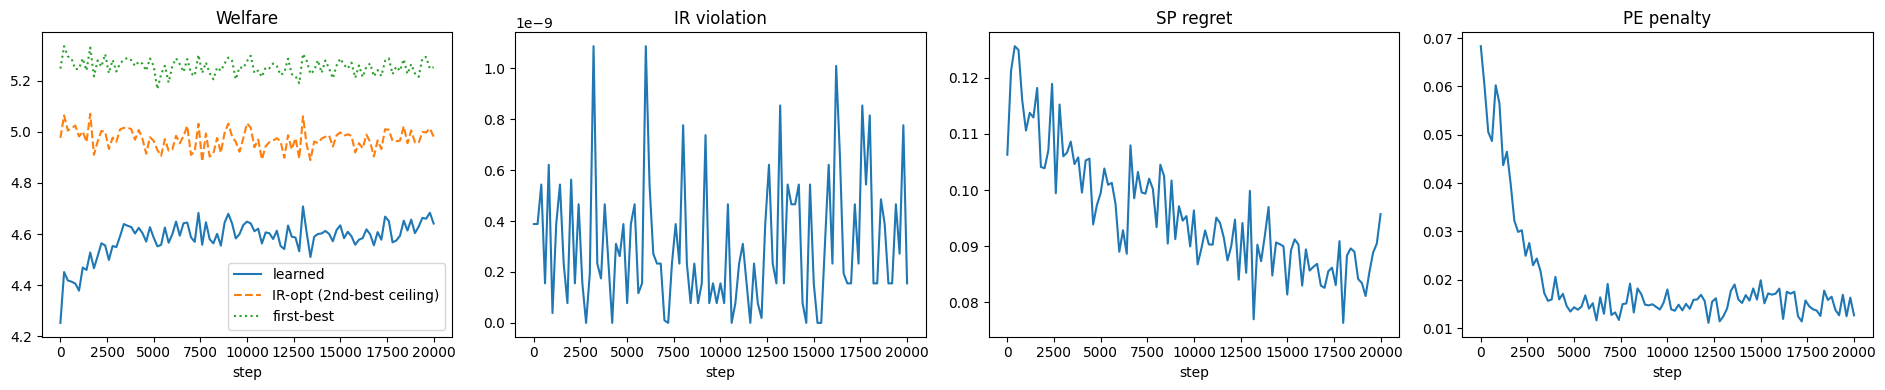

In [35]:
if _HAS_PLT and len(hist["step"]) > 1:
    fig, ax = plt.subplots(1, 4, figsize=(19, 4))
    ax[0].plot(hist["step"], hist["welfare"], label="learned")
    ax[0].plot(hist["step"], hist["oracle_ir"], "--", label="IR-opt (2nd-best ceiling)")
    ax[0].plot(hist["step"], hist["oracle_fb"], ":", label="first-best")
    ax[0].set_title("Welfare"); ax[0].set_xlabel("step"); ax[0].legend()
    ax[1].plot(hist["step"], hist["ir"]); ax[1].set_title("IR violation"); ax[1].set_xlabel("step")
    ax[2].plot(hist["step"], hist["sp"]); ax[2].set_title("SP regret"); ax[2].set_xlabel("step")
    ax[3].plot(hist["step"], hist["pe"]); ax[3].set_title("PE penalty"); ax[3].set_xlabel("step")
    plt.tight_layout(); plt.show()
else:
    print("no matplotlib or not enough history")

## 10. 評価（確定化＝argmax の hard メカニズムで測定）

- **welfare ratio** = 学習機構の厚生 / IR-opt（1.0 に近いほど効率損失が小さい）。
- **IR-violation rate** はマスク厳守によりほぼ 0 になるはず（健全性チェック）。
- **SP regret** は誤申告で得られる平均的な利得（小さいほど耐戦略的）。

In [36]:
@torch.no_grad()
def evaluate(cfg, space, net, n_eval=4096):
    v = torch.empty(n_eval, cfg.num_agents, cfg.num_items,
                    device=device).uniform_(cfg.v_min, cfg.v_max)
    alpha = torch.empty(n_eval, cfg.num_agents,
                        device=device).uniform_(cfg.alpha_min, cfg.alpha_max)
    endow = space.random_endowment(n_eval, cfg.ensure_nonempty_endowment)
    U = allocation_utilities(space, v, alpha)
    mask = ir_feasible_mask(U, endow)

    oh = net.predict_onehot(v, alpha, mask)          # hard 配分
    EU = expected_utils(oh, U)
    welfare = EU.sum(1).mean().item()
    o_ir = oracle_welfare_ir(U, endow).mean().item()
    o_fb = oracle_welfare(U).mean().item()

    ir_gap = F.relu(outside_option(U, endow) - EU)
    ir_rate = (ir_gap > 1e-6).any(1).float().mean().item()

    alloc_fn = lambda vv, aa, mm, ee: net.predict_onehot(vv, aa, mm)
    sp = sp_regret(cfg, space, alloc_fn, v, alpha, U, endow, EU).item()
    pe = pe_violation_rate(U, oh.argmax(-1))

    metrics = {"welfare": welfare, "ir_opt": o_ir, "first_best": o_fb,
               "ratio": welfare / max(o_ir, 1e-9),
               "ir_rate": ir_rate, "sp": sp, "pe_rate": pe}
    print(f"[EVAL hard] welfare = {welfare:.4f} | IR-opt = {o_ir:.4f} | "
          f"ratio = {metrics['ratio']:.4f} | first-best = {o_fb:.4f}")
    print(f"[EVAL hard] IR-violation rate = {ir_rate*100:.2f}%  |  SP regret (mean) = {sp:.4f}  "
          f"|  PE-violation rate = {pe*100:.2f}%")
    return metrics

eval_metrics = evaluate(cfg, space, net)

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.60 GiB. GPU 0 has a total capacity of 22.03 GiB of which 489.12 MiB is free. Including non-PyTorch memory, this process has 21.55 GiB memory in use. Of the allocated memory 20.50 GiB is allocated by PyTorch, and 839.55 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## 11. 1 サンプルの配分例（人間が読める形）

In [38]:
@torch.no_grad()
def show_example(cfg, space, net):
    v = torch.empty(1, cfg.num_agents, cfg.num_items, device=device).uniform_(cfg.v_min, cfg.v_max)
    alpha = torch.empty(1, cfg.num_agents, device=device).uniform_(cfg.alpha_min, cfg.alpha_max)
    endow = space.random_endowment(1, cfg.ensure_nonempty_endowment)
    U = allocation_utilities(space, v, alpha)
    mask = ir_feasible_mask(U, endow)
    alloc = net.predict_onehot(v, alpha, mask).argmax(-1)

    em = space.masks_for(endow)[0]; am = space.masks_for(alloc)[0]
    eu = U[0, :, endow[0]]; au = U[0, :, alloc[0]]
    print("v (valuations):")
    for i in range(cfg.num_agents):
        print(f"  agent {i}: " + ", ".join(f"{v[0,i,j]:.2f}" for j in range(cfg.num_items)) +
              f"   alpha={alpha[0,i]:.2f}")
    print("endowment:")
    for i in range(cfg.num_agents):
        print(f"  agent {i}: items={[j for j in range(cfg.num_items) if em[i,j]>0.5]}  u={eu[i]:.3f}")
    print("learned allocation:")
    for i in range(cfg.num_agents):
        print(f"  agent {i}: items={[j for j in range(cfg.num_items) if am[i,j]>0.5]}  u={au[i]:.3f}",
              "  (IR ok)" if au[i] >= eu[i]-1e-5 else "  (IR VIOLATED)")
    print(f"welfare: endow={eu.sum():.3f}  learned={au.sum():.3f}")

show_example(cfg, space, net)

v (valuations):
  agent 0: 0.53, 0.70, 0.37, 0.84, 0.91, 0.76, 0.26   alpha=0.00
  agent 1: 0.03, 0.57, 0.64, 0.16, 0.81, 0.99, 0.46   alpha=0.00
  agent 2: 0.89, 0.36, 0.17, 0.19, 0.32, 0.20, 0.75   alpha=0.00
endowment:
  agent 0: items=[1]  u=0.704
  agent 1: items=[5, 6]  u=1.451
  agent 2: items=[0, 2, 3, 4]  u=1.569
learned allocation:
  agent 0: items=[3, 4]  u=1.750   (IR ok)
  agent 1: items=[2, 5]  u=1.629   (IR ok)
  agent 2: items=[0, 1, 6]  u=1.996   (IR ok)
welfare: endow=3.724  learned=5.375


## 12. 有名メカニズムとの比較 & 3次元マップ（SP × IR × Welfare）

学習機構が「ストリクトに他ベンチマークより理想的か」を見るため、同じ枠組みの有名メカニズムを
**全て同じ物差し（welfare・IR違反・SP regret・PE違反）**で測り、3次元（SP, IR, Welfare）にプロットします。

比較対象（すべて配分空間 K=nᵏ を列挙して計算、決定的メカニズム）:
- **Endowment（現状維持/no-trade）**: 交換しない。SP=0, IR=0 だが非効率（PE違反大）。下限。
- **First-best（功利主義最適）**: welfare 最大・IR 無視。効率上限だが IR/SP を破る。
- **IR-opt welfare**: IR の中で welfare 最大（= PE+IR の welfare 天井、ただし非SP）。
- **Nash (IR)**: ナッシュ交渉解（余剰の積を最大化、公平）。
- **Egalitarian (IR)**: マックスミン（最も不遇な人の余剰を最大化、ロールズ的）。
- **Serial-dict (IR)**: 優先順位による逐次独裁（PE・ほぼ SP。論文 φ^IP の基数版アナログ）。
- **Learned (NN)**: 学習した機構（hard=argmax）。

**理想の位置 = SP 小・IR 小・Welfare 大**。学習機構がこの方向で他点を支配できているかを下で判定します。

> 補足: **PE違反率**も併記します（「他の配分にパレート支配されている割合」）。welfare最大系・Nash・max-min・serial は構造上ほぼ 0、
> 一方 **学習機構は SP とのトレードオフで PE を犠牲にしている可能性**が高く、ここが後述の「PE にすべき」議論の核心です。

In [39]:
# ---- 列挙ベースの有名メカニズム（U[B,A,K] と IR マスクを再利用） ----
# (pe_violation_rate は損失セルで定義済み)
def _argmax_masked(score, mask):
    return score.masked_fill(mask < 0.5, float('-inf')).argmax(-1)

def sel_first_best(U, mask, outside):           # 功利主義最適 (IR無視)
    return U.sum(1).argmax(-1)
def sel_ir_welfare(U, mask, outside):           # IR内 welfare 最大 (PE+IR)
    return _argmax_masked(U.sum(1), mask)
def sel_nash(U, mask, outside):                 # ナッシュ交渉 (IR), 公平
    s = (U - outside.unsqueeze(2)).clamp(min=0) + 1e-6
    return _argmax_masked(s.log().sum(1), mask)
def sel_egal(U, mask, outside):                 # マックスミン (IR), ロールズ
    return _argmax_masked((U - outside.unsqueeze(2)).min(1).values, mask)
def sel_serial(U, mask, outside):               # 逐次独裁/優先順位 (IR) -- SP寄り・PE
    B, A, K = U.shape
    feas = mask.clone()
    ar = torch.arange(K, device=U.device).float().unsqueeze(0)
    for i in range(A):
        ui = U[:, i, :].masked_fill(feas < 0.5, float('-inf'))
        feas = feas * (ui >= ui.max(1, keepdim=True).values - 1e-6).float()
    return torch.where(feas > 0.5, ar, ar + 1e18).argmin(-1)       # tie: 最小index

def _one_hot(idx, K, device):
    oh = torch.zeros(idx.shape[0], K, device=device)
    oh.scatter_(1, idx.view(-1, 1), 1.0)
    return oh

def benchmark_fn(space, select):
    def f(v, a, mask, endow):
        U = allocation_utilities(space, v, a)
        out = outside_option(U, endow)
        return _one_hot(select(U, mask, out), space.K, v.device)
    return f

def endowment_fn(space):
    def f(v, a, mask, endow):
        return _one_hot(endow, space.K, v.device)
    return f

In [40]:
@torch.no_grad()
def compare_and_plot(cfg, space, net, n_eval=2048):
    v = torch.empty(n_eval, cfg.num_agents, cfg.num_items, device=device).uniform_(cfg.v_min, cfg.v_max)
    a = torch.empty(n_eval, cfg.num_agents, device=device).uniform_(cfg.alpha_min, cfg.alpha_max)
    endow = space.random_endowment(n_eval, cfg.ensure_nonempty_endowment)
    U = allocation_utilities(space, v, a)
    mask = ir_feasible_mask(U, endow)
    outside = outside_option(U, endow)
    o_ir = oracle_welfare_ir(U, endow).mean().item()

    mechs = {
        "Endowment":        endowment_fn(space),
        "First-best":       benchmark_fn(space, sel_first_best),
        "IR-opt welfare":   benchmark_fn(space, sel_ir_welfare),
        "Nash (IR)":        benchmark_fn(space, sel_nash),
        "Egalitarian (IR)": benchmark_fn(space, sel_egal),
        "Serial-dict (IR)": benchmark_fn(space, sel_serial),
        "Learned (NN)":     (lambda vv, aa, mm, ee: net.predict_onehot(vv, aa, mm)),
    }
    rows = []
    print(f"{'Mechanism':<18}{'Welfare':>10}{'W/IRopt':>9}{'IR':>9}{'SP':>9}{'PE-viol':>9}")
    print("-" * 64)
    for name, fn in mechs.items():
        oh = fn(v, a, mask, endow)
        EU = expected_utils(oh, U)
        welfare = EU.sum(1).mean().item()
        ir = F.relu(outside - EU).mean().item()
        sp = sp_regret(cfg, space, fn, v, a, U, endow, EU).item()
        pe = pe_violation_rate(U, oh.argmax(-1))
        rows.append({"name": name, "welfare": welfare, "ir": ir, "sp": sp, "pe": pe})
        print(f"{name:<18}{welfare:>10.4f}{welfare/max(o_ir,1e-9):>9.3f}{ir:>9.4f}{sp:>9.4f}{pe*100:>8.1f}%")

    # ---- 支配判定: Learned が各点を (welfare>=, IR<=, SP<=, どこか厳密) で上回るか ----
    L = next(r for r in rows if r["name"] == "Learned (NN)")
    print("\nLearned(NN) が各ベンチマークを支配 (welfare>=, IR<=, SP<=, かつどこか厳密) しているか:")
    for r in rows:
        if r["name"] == "Learned (NN)":
            continue
        dom = (L["welfare"] >= r["welfare"] - 1e-4 and L["ir"] <= r["ir"] + 1e-4
               and L["sp"] <= r["sp"] + 1e-4
               and (L["welfare"] > r["welfare"] + 1e-4 or L["ir"] < r["ir"] - 1e-4
                    or L["sp"] < r["sp"] - 1e-4))
        print(f"  vs {r['name']:<18}: {'DOMINATES' if dom else 'no'}")

    # ---- 3D マップ + 2D 投影 ----
    if _HAS_PLT:
        from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
        fig = plt.figure(figsize=(13, 5.5))
        ax = fig.add_subplot(1, 2, 1, projection="3d")
        for r in rows:
            star = (r["name"] == "Learned (NN)")
            ax.scatter(r["sp"], r["ir"], r["welfare"],
                       s=240 if star else 80, marker="*" if star else "o")
            ax.text(r["sp"], r["ir"], r["welfare"], "  " + r["name"], fontsize=8)
        ax.set_xlabel("SP regret (low=good)")
        ax.set_ylabel("IR viol. (low=good)")
        ax.set_zlabel("Welfare (high=good)")
        ax.set_title("3D frontier: SP x IR x Welfare")

        ax2 = fig.add_subplot(1, 2, 2)
        for r in rows:
            star = (r["name"] == "Learned (NN)")
            ax2.scatter(r["sp"], r["welfare"], s=240 if star else 80,
                        marker="*" if star else "o")
            ax2.annotate(r["name"], (r["sp"], r["welfare"]), fontsize=8,
                         xytext=(4, 4), textcoords="offset points")
        ax2.axhline(o_ir, ls="--", c="gray", lw=1, label="IR-opt ceiling")
        ax2.set_xlabel("SP regret (low=good)")
        ax2.set_ylabel("Welfare (high=good)")
        ax2.set_title("2D: SP vs Welfare (ideal=top-left)")
        ax2.legend()
        plt.tight_layout(); plt.show()
    return rows

bench_rows = compare_and_plot(cfg, space, net)

Mechanism            Welfare  W/IRopt       IR       SP  PE-viol
----------------------------------------------------------------


OutOfMemoryError: CUDA out of memory. Tried to allocate 822.00 MiB. GPU 0 has a total capacity of 22.03 GiB of which 489.12 MiB is free. Including non-PyTorch memory, this process has 21.55 GiB memory in use. Of the allocated memory 20.59 GiB is allocated by PyTorch, and 749.59 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## 13. 実験の記録（ハイパラ × 結果をファイルに保存）

各実験ごとに **設定(全ハイパラ) + 最終メトリクス(welfare/IR/SP/PE) + ベンチマーク比較 + 学習曲線 + モデル** を
「1 実験 = 1 フォルダ」で保存し、さらに **全実験を 1 行ずつまとめたマスター表 `experiments.csv`** に追記します。
`Config.tag` を実験ごとに変えれば表で区別できます（例: `cfg.tag = "alpha0_sp_strong"`）。

> ⚠️ **Colab の落とし穴:** `/content` 以下は**ランタイム切断で全部消えます**。記録を残すなら次セルの
> `USE_DRIVE = True` にして **Google Drive に保存**してください（セッションをまたいで残る）。
> Drive を使わないときは、各 run の zip を都度ダウンロードしてください（下で自動ダウンロードします）。

In [41]:
import os, json, time
try:
    import pandas as pd
    _HAS_PD = True
except Exception:
    _HAS_PD = False

USE_DRIVE = False   # ★ True にすると Google Drive に保存 (記録が消えないので推奨)
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    RESULTS_DIR = "/content/drive/MyDrive/multi_item_mech_runs"
else:
    RESULTS_DIR = "runs"        # = /content/runs (ランタイム切断で消える)
os.makedirs(RESULTS_DIR, exist_ok=True)
MASTER_CSV = os.path.join(RESULTS_DIR, "experiments.csv")
print("results dir :", os.path.abspath(RESULTS_DIR))
print("master table:", MASTER_CSV)

results dir : /content/runs
master table: runs/experiments.csv


In [ ]:
def log_experiment(cfg, net, space, hist=None, eval_metrics=None, bench_rows=None):
    ts = time.strftime("%Y%m%d_%H%M%S")
    run_id = f"{ts}_{cfg.tag}"
    run_dir = os.path.join(RESULTS_DIR, run_id)
    os.makedirs(run_dir, exist_ok=True)

    if eval_metrics is None:                 # 未計算なら評価し直す
        eval_metrics = evaluate(cfg, space, net)
    if bench_rows is None:                    # 未計算ならベンチ比較し直す
        bench_rows = compare_and_plot(cfg, space, net)

    # 1) フル記録 JSON (config + 最終メトリクス + ベンチ表 + 学習曲線)
    record = {"run_id": run_id, "tag": cfg.tag, "notes": cfg.notes,
              "config": asdict(cfg), "eval": eval_metrics,
              "benchmarks": bench_rows, "history": (hist or {})}
    with open(os.path.join(run_dir, "record.json"), "w", encoding="utf-8") as f:
        json.dump(record, f, ensure_ascii=False, indent=2)

    # 2) モデル
    torch.save({"state_dict": net.state_dict(), "cfg": asdict(cfg)},
               os.path.join(run_dir, "model.pt"))

    # 3) 学習曲線の画像
    if _HAS_PLT and hist and len(hist.get("step", [])) > 1:
        fig, ax = plt.subplots(1, 4, figsize=(19, 4))
        ax[0].plot(hist["step"], hist["welfare"]); ax[0].plot(hist["step"], hist["oracle_ir"], "--")
        ax[0].set_title("welfare"); ax[1].plot(hist["step"], hist["ir"]); ax[1].set_title("IR")
        ax[2].plot(hist["step"], hist["sp"]); ax[2].set_title("SP")
        ax[3].plot(hist["step"], hist["pe"]); ax[3].set_title("PE")
        fig.savefig(os.path.join(run_dir, "curves.png"), dpi=110, bbox_inches="tight")
        plt.close(fig)

    # 4) マスター表に 1 行追記 (= ハイパラ x 結果の比較表)
    row = {
        "run_id": run_id, "tag": cfg.tag,
        "n": cfg.num_agents, "k": cfg.num_items,
        "alpha_min": cfg.alpha_min, "alpha_max": cfg.alpha_max,
        "steps": cfg.steps, "lr": cfg.lr, "hidden": cfg.hidden, "depth": cfg.depth,
        "welfare_weight": cfg.welfare_weight, "lambda_sp": round(cfg.lambda_sp, 3),
        "lambda_pe": round(cfg.lambda_pe, 3), "rho": round(cfg.rho, 2),
        "misreport_samples": cfg.misreport_samples,
        "welfare": round(eval_metrics["welfare"], 4),
        "ratio_vs_IRopt": round(eval_metrics["ratio"], 4),
        "IR_rate%": round(eval_metrics["ir_rate"] * 100, 3),
        "SP": round(eval_metrics["sp"], 4),
        "PE_rate%": round(eval_metrics["pe_rate"] * 100, 2),
        "notes": cfg.notes,
    }
    if _HAS_PD:
        df_new = pd.DataFrame([row])
        df = pd.concat([pd.read_csv(MASTER_CSV), df_new], ignore_index=True) \
             if os.path.exists(MASTER_CSV) else df_new
        df.to_csv(MASTER_CSV, index=False)
    else:
        import csv
        write_header = not os.path.exists(MASTER_CSV)
        with open(MASTER_CSV, "a", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=list(row.keys()))
            if write_header: w.writeheader()
            w.writerow(row)

    print(f"[logged] run folder : {run_dir}")
    print(f"[master] appended to: {MASTER_CSV}")
    return run_dir

# 直前の学習結果 (cfg/net/hist/eval_metrics/bench_rows) をそのまま記録
run_dir = log_experiment(cfg, net, space,
                         hist=globals().get("hist"),
                         eval_metrics=globals().get("eval_metrics"),
                         bench_rows=globals().get("bench_rows"))

# Drive を使わない場合の保険: run フォルダを zip 化してダウンロード
try:
    import shutil
    from google.colab import files
    zip_path = shutil.make_archive(run_dir, "zip", run_dir)
    files.download(zip_path)
except Exception as e:
    print("(zip ダウンロードはスキップ:", e, ")")

## 14. これまでの全実験を表で見る

`experiments.csv` を読み込み、ハイパラ × 結果の一覧を表示します。`Config.tag` を変えて再実行 → このセルを再表示すれば、行が増えていきます。

In [ ]:
if _HAS_PD and os.path.exists(MASTER_CSV):
    df = pd.read_csv(MASTER_CSV)
    try:
        display(df)                 # Colab/Jupyter は整形表示
    except NameError:
        print(df.to_string())
else:
    print("まだ記録がありません (上の記録セルを実行してください)")

## 15. 使い方とスケーリングのコツ

**複数実験を回して記録する手順**
1. （最初の1回）セル13で `USE_DRIVE = True` にして Drive 保存を有効化（記録を残すなら強く推奨）。
2. セル1の `Config` で **`tag` を実験ごとに変える**（例 `tag="exp_additive_PE"`）＋ハイパラを変更。
3. 「ランタイム → すべてを実行」。→ 学習〜評価〜ベンチ比較が走り、**自動で 1 フォルダに記録＋マスター表に1行追記**。
4. セル14（マスター表）を見れば、これまでの全実験がハイパラ×結果の表で並ぶ。
- 1 実験 = `runs/<日時>_<tag>/` に `record.json`(全部) / `model.pt` / `curves.png`。横断比較は `runs/experiments.csv`。
- Drive を使わない場合は run の zip が自動ダウンロードされる（`/content` は切断で消えるため）。

**設定変更:** セル1の `Config` を編集 → 「ランタイム → すべてを実行」。

**よく変える項目**
- `num_agents` (n), `num_items` (k): 問題サイズ。**K = nᵏ が爆発**するので注意。
- `alpha_min`, `alpha_max`: シナジー α の範囲。純加法=`(0,0)`、補完財=`(0,0.5)`、代替財含む=`(-0.5,0.5)`。
- `lambda_sp`, `rho`, `sp_target`: SP の罰則強度（耐戦略性 vs 効率のトレードオフ）。
- `batch_size`, `misreport_samples`: SP 近似の精度とメモリ。大きい K では下げる。
- `steps`, `lr`, `anneal_last_steps`, `temp_end`: 学習量と確定化スケジュール。

**OOM（メモリ不足）になったら**
1. `misreport_samples` を 32→16→8 に下げる
2. `batch_size` を 512→256→128 に下げる
3. それでも厳しい K（例 n=3,k=10 で K=59049）は、SP をミニバッチ分割評価する改造が必要。

**目安（T4 GPU）**: n=3,k=5 (K=243) は数分。n=3,k=8 (K=6561) はメモリ次第で `misreport_samples` 要調整。
